# 04 — Run T and VT

For each of the first `N_QUESTIONS` questions (in the fixed order from notebook 03), score A–D twice:
- **T**: transcript + question + options;
- **VT**: the same text + 64 silent video frames.

Each result is appended to `outputs/results.jsonl` as soon as it is computed. Questions already in the file are skipped,
so you can stop at any time, or raise `N_QUESTIONS` and rerun — only new questions are computed.

The run itself uses no answer keys; they are loaded only in the analysis section at the end.

In [14]:
N_QUESTIONS = None  # set to None to run all 598 questions (~10 h on CPU, ~1 min per question)

In [15]:
import sys, json, time, tomllib
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import qwen_omni as qo

CFG = tomllib.loads((ROOT / "configs/pilot.toml").read_text())
OUT = ROOT / "outputs/results.jsonl"
OUT.parent.mkdir(exist_ok=True)

questions = pd.read_parquet(ROOT / "data/processed/emotion_questions.parquet").head(N_QUESTIONS)
print(f"{len(questions)} questions selected")

598 questions selected


## Load the model (~18 GB RAM, a few minutes)

In [16]:
processor, model = qo.load(CFG["model_revision"])

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1346 [00:00<?, ?it/s]

[transformers] Qwen2_5OmniThinkerForConditionalGeneration LOAD REPORT from: Qwen/Qwen2.5-Omni-7B
Key                                                                                                      | Status     |  | 
---------------------------------------------------------------------------------------------------------+------------+--+-
token2wav.code2wav_bigvgan_model.resblocks.{0...17}.convs2.{0, 1, 2}.weight                              | UNEXPECTED |  | 
talker.model.layers.{0...23}.self_attn.v_proj.bias                                                       | UNEXPECTED |  | 
token2wav.code2wav_dit_model.transformer_blocks.{0...21}.ff.ff.{0, 3}.bias                               | UNEXPECTED |  | 
token2wav.code2wav_bigvgan_model.resblocks.{0...17}.convs2.{0, 1, 2}.bias                                | UNEXPECTED |  | 
token2wav.code2wav_bigvgan_model.resblocks.{0...17}.activations.{0, 1, 2, 3, 4, 5}.act.alpha             | UNEXPECTED |  | 
talker.model.layers.{0...23}.self_a

## Show the exact prompt for the first question

In [17]:
first = questions.iloc[0]
print(qo.make_inputs(processor, qo.SYSTEM_PROMPT, qo.build_prompt(first))[1])

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Transcript of the dialogue in the clip:
(no dialogue)

Question: How does the man feel about knocking on the door?
A. The man expresses sadness that he won't come inside.
B. The man expresses fear that there might not be anyone inside.
C. The man expresses annoyance.
D. The man expresses nervousness.

Answer with the option's letter only.<|im_end|>
<|im_start|>assistant



## Run

In [18]:
done = {(r["question_id"], r["condition"]) for r in map(json.loads, OUT.open())} if OUT.exists() else set()
print(f"{len(done)} results already in {OUT.name}")

for q in tqdm(questions.itertuples(), total=len(questions), unit="question"):
    user_text = qo.build_prompt(q._asdict())
    for condition in ["T", "VT"]:
        if (q.question_id, condition) in done:
            continue
        t0 = time.time()
        if condition == "T":
            inputs, _ = qo.make_inputs(processor, qo.SYSTEM_PROMPT, user_text)
        else:
            video = ROOT / "data/raw/all_videos" / f"{q.movie_title}.mp4"
            frames, fps = qo.sample_frames(video, q.t_i, q.t_j, q.n_frames, CFG["max_pixels"])
            inputs, _ = qo.make_inputs(processor, qo.SYSTEM_PROMPT, user_text, frames, fps)
        r = qo.score_options(model, processor, inputs)
        row = {"order": q.order, "question_id": q.question_id, "condition": condition,
               **{f"prob_{L}": p for L, p in zip(qo.LETTERS, r["prob"])},
               "mass_on_letters": r["mass_on_letters"], "n_input_tokens": r["n_input_tokens"],
               "seconds": round(time.time() - t0, 1), "model_revision": CFG["model_revision"],
               "n_frames": q.n_frames if condition == "VT" else 0, "max_pixels": CFG["max_pixels"]}
        with OUT.open("a") as f:
            f.write(json.dumps(row) + "\n")

1196 results already in results.jsonl


  0%|          | 0/598 [00:00<?, ?question/s]

## Results so far

In [19]:
results = pd.read_json(OUT, lines=True).drop_duplicates(["question_id", "condition"])
results.pivot(index=["order", "question_id"], columns="condition", values=["prob_A", "prob_B", "prob_C", "prob_D", "seconds"]).round(3)

prob_A        prob_B        prob_C        prob_D         \
condition              T     VT      T     VT      T     VT      T     VT   
order question_id                                                           
0     FH-76        0.024  0.002  0.262  0.942  0.159  0.020  0.555  0.037   
1     97rJU        0.680  0.666  0.056  0.080  0.250  0.245  0.014  0.009   
2     cP4lM        0.998  0.994  0.000  0.000  0.001  0.000  0.002  0.005   
3     XESWo        0.037  0.265  0.003  0.008  0.955  0.721  0.004  0.006   
4     6p7dK        0.315  0.162  0.667  0.184  0.016  0.641  0.002  0.013   
...                  ...    ...    ...    ...    ...    ...    ...    ...   
593   SrYXo        0.011  0.010  0.007  0.016  0.981  0.969  0.001  0.006   
594   JJhhE        0.002  0.003  0.997  0.996  0.000  0.000  0.001  0.001   
595   9mkao        0.860  0.959  0.062  0.023  0.029  0.014  0.049  0.004   
596   4DiV2        0.451  0.794  0.398  0.177  0.005  0.001  0.146  0.027   
597   0-VJ7        0.108  0.069  0.703  0.841  0.178  0.089  0.011  0.001   

                  seconds         
condition               T     VT  
order question_id                 
0     FH-76           1.1   59.8  
1     97rJU           1.7   61.3  
2     cP4lM           4.2   64.7  
3     XESWo           2.2   61.8  
4     6p7dK           1.3   62.6  
...                   ...    ...  
593   SrYXo           2.4  115.9  
594   JJhhE           2.3  117.0  
595   9mkao           2.9  115.7  
596   4DiV2           3.0  117.6  
597   0-VJ7           2.3  118.3  

[598 rows x 10 columns]

## How did the model do?

Now we open the answer key (kept separate so it can't leak into the run).
- **prediction** = letter with the highest probability
- **confidence** = that highest probability
- **p_correct** = probability the model gave to the correct letter

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

FIGURES = ROOT / "outputs/figures"
FIGURES.mkdir(exist_ok=True)
COLORS = {"T": "tab:blue", "VT": "tab:orange"}

keys = pd.read_parquet(ROOT / "data/processed/answer_keys.parquet")[["question_id", "correct_answer_key"]]
cues = pd.read_parquet(ROOT / "data/processed/emotion_questions.parquet")[["question_id", "cue_visual_any"]]
prob_cols = [f"prob_{L}" for L in qo.LETTERS]

df = (pd.read_json(OUT, lines=True).drop_duplicates(["question_id", "condition"])
      .merge(keys, on="question_id").merge(cues, on="question_id"))
df = df[df.groupby("question_id").condition.transform("nunique") == 2]  # only questions with both T and VT
df["prediction"] = df[prob_cols].idxmax(axis=1).str[-1]
df["confidence"] = df[prob_cols].max(axis=1)
df["p_correct"] = df.apply(lambda r: r[f"prob_{r.correct_answer_key}"], axis=1)
df["correct"] = df["prediction"] == df["correct_answer_key"]
df[["order", "question_id", "condition", "correct_answer_key", "prediction", "confidence", "p_correct", "correct"]].round(3)

,order,question_id,condition,correct_answer_key,prediction,confidence,p_correct,correct
0,0,FH-76,T,D,D,0.555,0.555,True
1,0,FH-76,VT,D,B,0.942,0.037,False
2,1,97rJU,T,B,A,0.680,0.056,False
3,1,97rJU,VT,B,A,0.666,0.080,False
4,2,cP4lM,T,A,A,0.998,0.998,True
...,...,...,...,...,...,...,...,...
1191,595,9mkao,VT,C,A,0.959,0.014,False
1192,596,4DiV2,T,B,A,0.451,0.398,False
1193,596,4DiV2,VT,B,A,0.794,0.177,False
1194,597,0-VJ7,T,A,B,0.703,0.108,False


In [21]:
summary = df.groupby("condition").agg(
    n=("correct", "size"),
    accuracy=("correct", "mean"),
    mean_confidence=("confidence", "mean"),
    mean_p_correct=("p_correct", "mean"),
    conf_when_right=("confidence", lambda c: c[df.loc[c.index, "correct"]].mean()),
    conf_when_wrong=("confidence", lambda c: c[~df.loc[c.index, "correct"]].mean()),
)
summary.round(3)

,n,accuracy,mean_confidence,mean_p_correct,conf_when_right,conf_when_wrong
condition,,,,,,
T,598,0.535,0.753,0.493,0.801,0.697
VT,598,0.554,0.791,0.532,0.853,0.715


Same questions, T vs VT: did adding the video fix or break answers?

In [22]:
wide = df.pivot(index="question_id", columns="condition", values=["correct", "p_correct", "confidence"])
wide = wide.dropna()  # only questions that have both T and VT
print(f"{len(wide)} questions with both conditions")
pd.crosstab(wide["correct"]["T"].map({True: "T right", False: "T wrong"}),
            wide["correct"]["VT"].map({True: "VT right", False: "VT wrong"}))

598 questions with both conditions


VT,VT right,VT wrong
T,,
T right,274,46
T wrong,57,221


Accuracy split by whether the annotators said the answer needs a visual cue (face / body).

In [23]:
df.pivot_table(index="cue_visual_any", columns="condition", values="correct", aggfunc=["mean", "size"]).round(3)

mean        size     
condition           T     VT    T   VT
cue_visual_any                        
False           0.478  0.489   92   92
True            0.545  0.565  506  506

## Plots

Each plot is shown and saved to `outputs/figures/`.

### Accuracy

Bars are accuracy, error bars are 95% Wilson intervals, the dashed line is chance (25%).

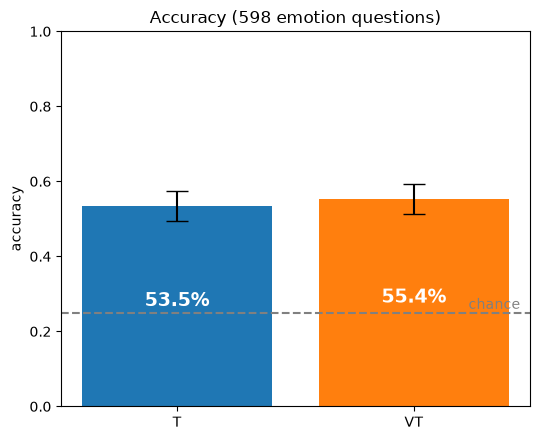

In [24]:
def wilson(k, n, z=1.96):
    """95% confidence interval for a proportion k/n (more accurate than the normal approximation)."""
    p = k / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * (p * (1 - p) / n + z**2 / (4 * n**2)) ** 0.5 / (1 + z**2 / n)
    return centre - half, centre + half

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for i, cond in enumerate(["T", "VT"]):
    g = df[df.condition == cond]
    acc = g.correct.mean()
    lo, hi = wilson(g.correct.sum(), len(g))
    ax.bar(i, acc, color=COLORS[cond], yerr=[[acc - lo], [hi - acc]], capsize=8)
    ax.text(i, acc / 2, f"{acc:.1%}", ha="center", color="white", fontweight="bold", fontsize=14)
ax.axhline(0.25, ls="--", c="gray")
ax.text(1.45, 0.26, "chance", color="gray", ha="right")
ax.set(xticks=[0, 1], xticklabels=["T", "VT"], ylim=(0, 1), ylabel="accuracy",
       title=f"Accuracy ({len(wide)} emotion questions)")
fig.tight_layout()
fig.savefig(FIGURES / "accuracy.png", dpi=200)
plt.show()

### Confidence of right vs wrong answers

Filled bars = right answers, hatched bars = wrong answers. Confidence is the top probability, so it is always at least 0.25.

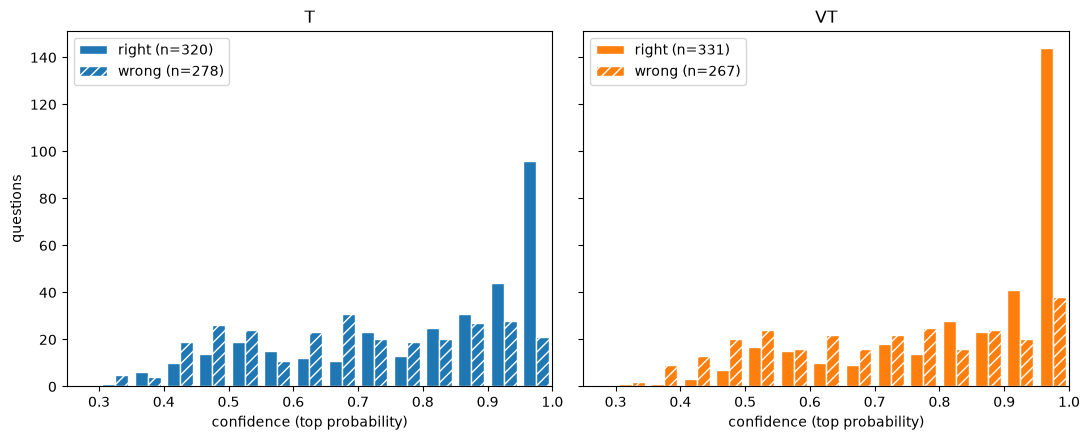

In [25]:
bins = [i / 20 for i in range(5, 21)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, cond in zip(axes, ["T", "VT"]):
    g = df[df.condition == cond]
    right, wrong = g.loc[g.correct, "confidence"], g.loc[~g.correct, "confidence"]
    _, _, (bars_right, bars_wrong) = ax.hist(
        [right, wrong], bins=bins, color=[COLORS[cond]] * 2, edgecolor="white",
        label=[f"right (n={len(right)})", f"wrong (n={len(wrong)})"])
    for bar in bars_wrong:
        bar.set_hatch("///")
    ax.set(xlim=(0.25, 1), xlabel="confidence (top probability)", title=cond)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(loc="upper left")
axes[0].set_ylabel("questions")
fig.tight_layout()
fig.savefig(FIGURES / "confidence_right_vs_wrong.png", dpi=200)
plt.show()

### Confidently wrong

Share of all questions answered wrong with confidence of at least `HIGH_CONFIDENCE`: the critical failure from the hypothesis.

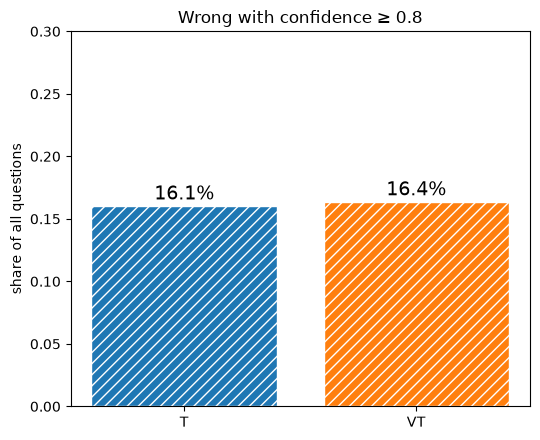

In [26]:
HIGH_CONFIDENCE = 0.8

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for i, cond in enumerate(["T", "VT"]):
    g = df[df.condition == cond]
    rate = (~g.correct & (g.confidence >= HIGH_CONFIDENCE)).mean()
    ax.bar(i, rate, color=COLORS[cond], hatch="///", edgecolor="white")
    ax.text(i, rate + 0.005, f"{rate:.1%}", ha="center", fontsize=14)
ax.set(xticks=[0, 1], xticklabels=["T", "VT"], ylim=(0, 0.3), ylabel="share of all questions",
       title=f"Wrong with confidence ≥ {HIGH_CONFIDENCE}")
fig.tight_layout()
fig.savefig(FIGURES / "confidently_wrong.png", dpi=200)
plt.show()